In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ecommerce_clean_data.csv')

In [3]:
df.head()

,OrderID,OrderDate,CustomerID,PaymentMethod,OrderStatus,CustomerName,Gender,Age,City,Region,...,Profit,ProductName,Category,CostPrice,SellingPrice,Year,Month,MonthName,YearMonth,ProfitMarginPct
0,O00001,2026-01-19,C0484,UPI,Delivered,Customer_0484,Female,31,Pune,West,...,12649.20,Mouse,Electronics,5353.0,10018.0,2026,1,January,2026-01,37.136683
1,O00001,2026-01-19,C0484,UPI,Delivered,Customer_0484,Female,31,Pune,West,...,6532.80,Shampoo,Beauty,3112.0,5568.0,2026,1,January,2026-01,41.167574
2,O00002,2026-02-14,C0450,Credit Card,Delivered,Customer_0450,Female,23,Hyderabad,South,...,3909.45,Table Lamp,Home,5905.0,10331.0,2026,2,February,2026-02,39.833613
3,O00002,2026-02-14,C0450,Credit Card,Delivered,Customer_0450,Female,23,Hyderabad,South,...,2006.80,Air Fryer,Home,3425.0,4363.0,2026,2,February,2026-02,12.776632
4,O00003,2025-11-21,C0523,Credit Card,Delivered,Customer_0523,Female,60,Delhi,North,...,4543.90,T-Shirt,Fashion,3999.0,6601.0,2025,11,November,2025-11,36.229758


In [4]:
df.shape

(12558, 27)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558 entries, 0 to 12557
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          12558 non-null  object 
 1   OrderDate        12558 non-null  object 
 2   CustomerID       12558 non-null  object 
 3   PaymentMethod    12558 non-null  object 
 4   OrderStatus      12558 non-null  object 
 5   CustomerName     12558 non-null  object 
 6   Gender           12558 non-null  object 
 7   Age              12558 non-null  int64  
 8   City             12558 non-null  object 
 9   Region           12558 non-null  object 
 10  SignupDate       12558 non-null  object 
 11  OrderDetailID    12558 non-null  object 
 12  ProductID        12558 non-null  object 
 13  Quantity         12558 non-null  int64  
 14  UnitPrice        12558 non-null  float64
 15  DiscountPct      12558 non-null  float64
 16  SalesAmount      12558 non-null  float64
 17  Profit      

In [6]:
df.describe()

,Age,Quantity,UnitPrice,DiscountPct,SalesAmount,Profit,CostPrice,SellingPrice,Year,Month,ProfitMarginPct
count,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000,12558.000000
mean,39.065377,2.501752,6272.299570,10.742156,14010.138708,4804.382457,3680.883023,6272.299570,2024.835165,6.002150,31.293145
std,12.303175,1.119501,3461.536155,7.112802,10628.052040,4894.725391,1846.766235,3461.536155,0.762190,3.287781,13.355564
min,18.000000,1.000000,319.000000,0.000000,239.250000,-2048.000000,232.000000,319.000000,2024.000000,1.000000,-10.940224
25%,28.000000,2.000000,3416.000000,5.000000,5949.000000,1342.400000,2400.000000,3416.000000,2024.000000,3.000000,21.079173
50%,40.000000,2.000000,6288.000000,10.000000,11210.400000,3215.600000,3640.000000,6288.000000,2025.000000,6.000000,32.433378
75%,50.000000,4.000000,8847.000000,15.000000,20044.800000,6608.400000,5353.000000,8847.000000,2025.000000,9.000000,42.278551
max,60.000000,4.000000,14270.000000,25.000000,57080.000000,30860.000000,6882.000000,14270.000000,2026.000000,12.000000,54.342273


In [7]:
# 🟢 STEP 5 — Business Question #1
# 💰 Sales Distribution
# Question:
# Individual transactions mein sales amount ka distribution kaisa hai?

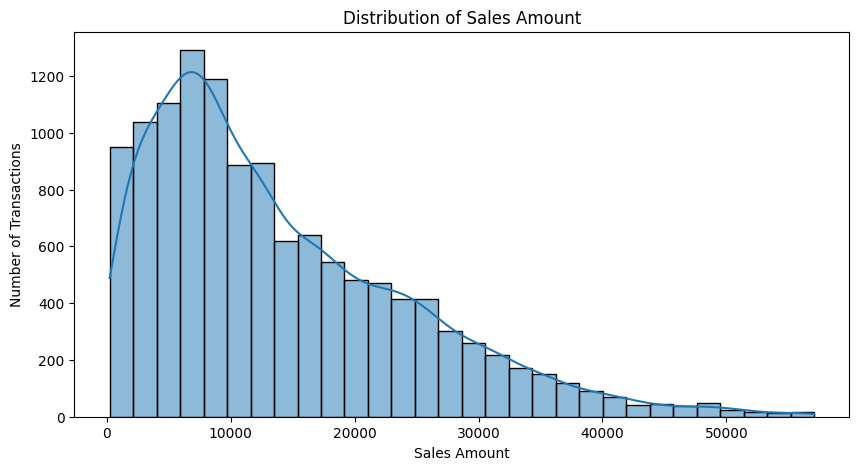

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['SalesAmount'],
    bins=30,
    kde=True
)

plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Number of Transactions')
plt.show()

In [10]:
# Profit Distribution

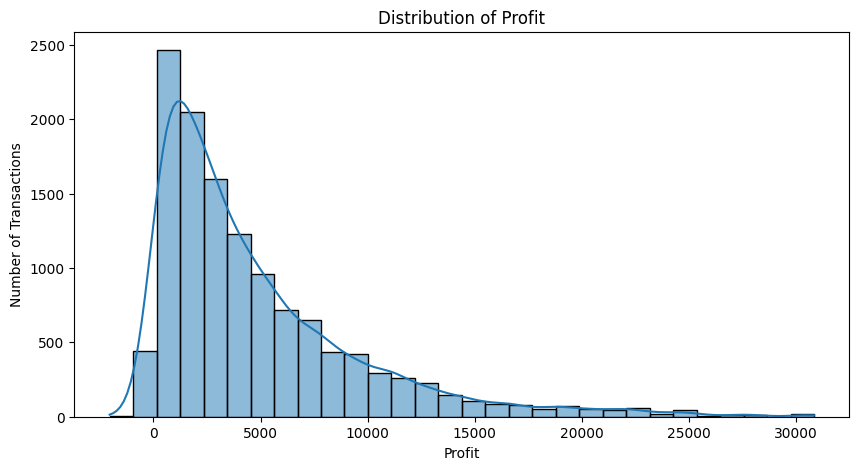

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Profit"],
    bins=30,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Transactions")
plt.show()

In [12]:
# 🟢 STEP 7 — Business Question #2
# 📅 Monthly Revenue Trend
# Question:
# Time ke saath sales ka behaviour kaisa hai?

In [13]:
monthly_sales = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("YearMonth")["SalesAmount"]
    .sum()
    .reset_index()
)

In [14]:
monthly_sales

,YearMonth,SalesAmount
0,2024-01,4690868.90
1,2024-02,4089338.70
2,2024-03,5296276.35
3,2024-04,4677015.85
4,2024-05,5020831.80
5,2024-06,5343347.60
6,2024-07,6165635.20
7,2024-08,5359728.15
8,2024-09,5302620.35
9,2024-10,4759925.10


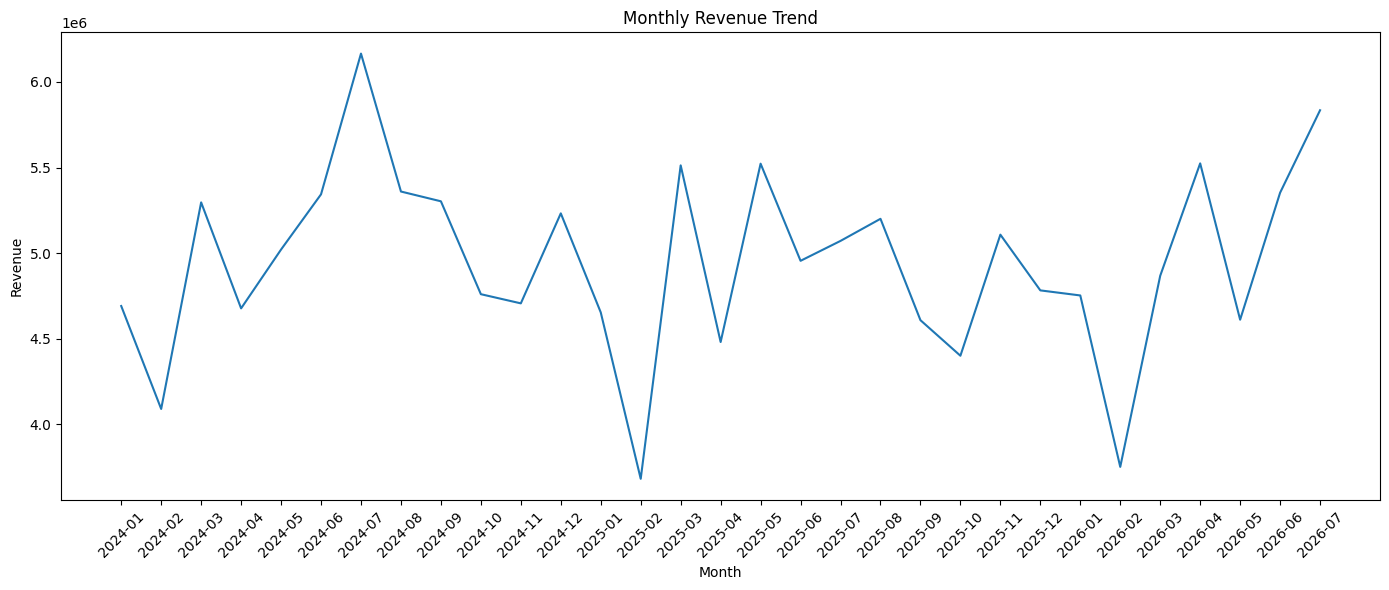

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["SalesAmount"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Monthly Profit

In [19]:
monthly_profit = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("YearMonth")["Profit"]
    .sum()
    .reset_index()
)

In [20]:
monthly_profit

,YearMonth,Profit
0,2024-01,1656481.90
1,2024-02,1447540.70
2,2024-03,1835204.35
3,2024-04,1561253.85
4,2024-05,1731669.80
5,2024-06,1860319.60
6,2024-07,2044670.20
7,2024-08,1813577.15
8,2024-09,1809531.35
9,2024-10,1623537.10


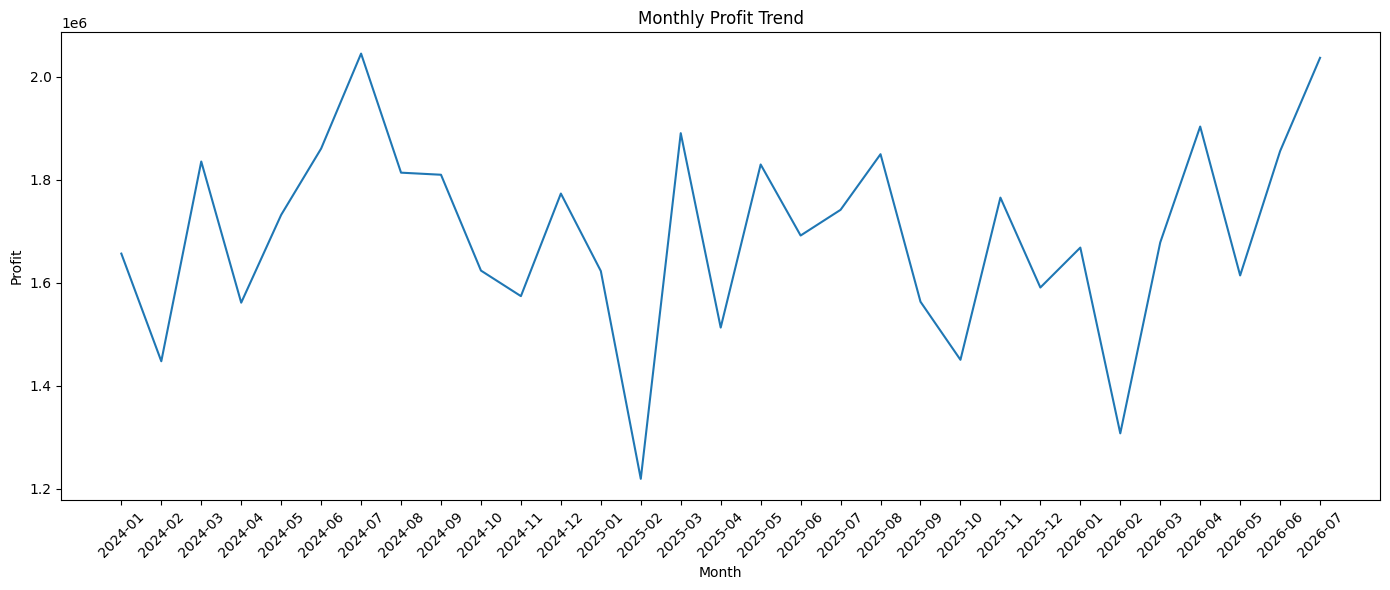

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit["YearMonth"],
    monthly_profit["Profit"]
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# 🟢 STEP 9 — Business Question #3
# 🛍️ Category Performance
# Question:
# Kaunsi category sabse zyada revenue generate kar rahi hai?

In [23]:
category_sales = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("Category")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
)

In [24]:
category_sales

Category
Home           41719144.50
Electronics    39483785.90
Fashion        30509991.50
Beauty         24937008.05
Books          16662009.60
Name: SalesAmount, dtype: float64

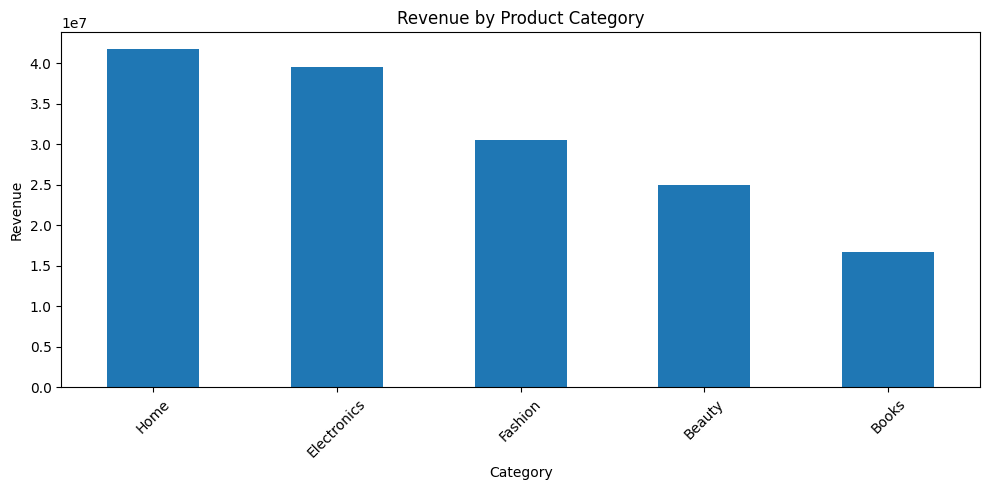

In [25]:
plt.figure(figsize=(10,5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Category Profit

In [27]:
category_profit = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

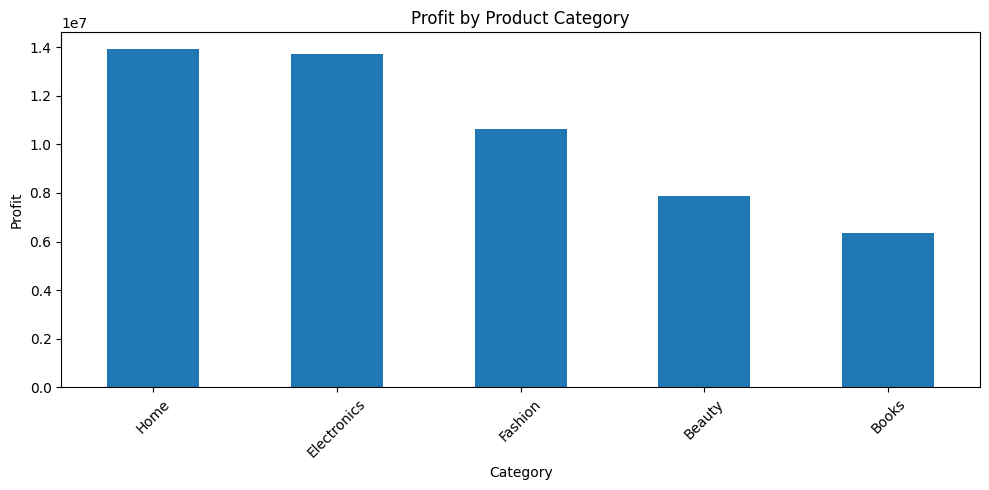

In [28]:
plt.figure(figsize=(10,5))

category_profit.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# 🟢 STEP 11 — Business Question #4
# 🌍 Region Performance
# Question:
# Kaunsa region best perform kar raha hai?

In [30]:
region_sales = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("Region")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
)

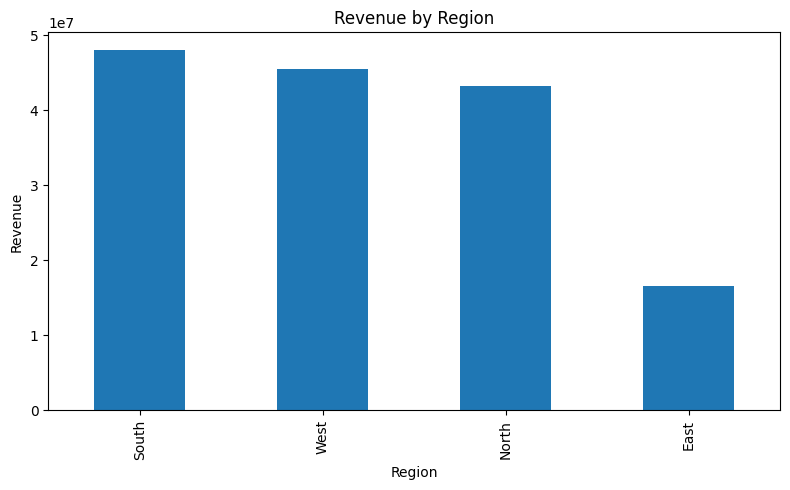

In [31]:
plt.figure(figsize=(8,5))

region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [32]:
# Customers kaunsa payment method zyada use kar rahe hain?

In [33]:
payment_analysis = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("PaymentMethod")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
)

In [34]:
payment_analysis

PaymentMethod
UPI            1505
Credit Card    1122
Debit Card      685
COD             621
Net Banking     453
Name: OrderID, dtype: int64

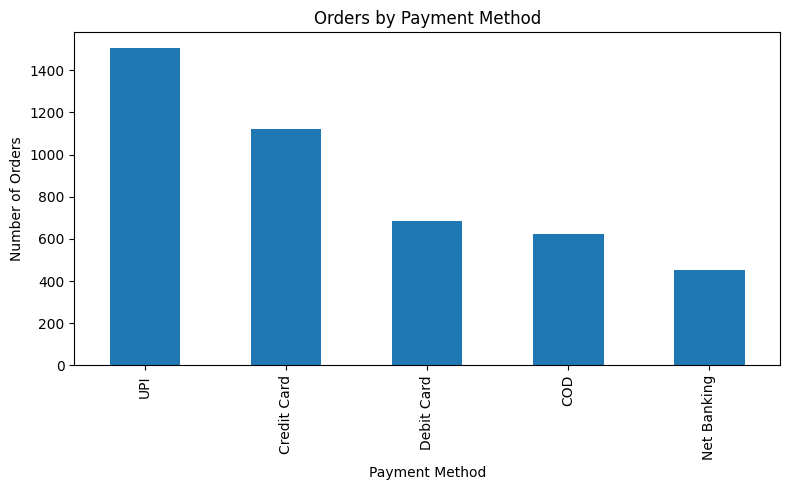

In [35]:
plt.figure(figsize=(8,5))

payment_analysis.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [36]:
# Discount badhne par profit ka kya behaviour hai?

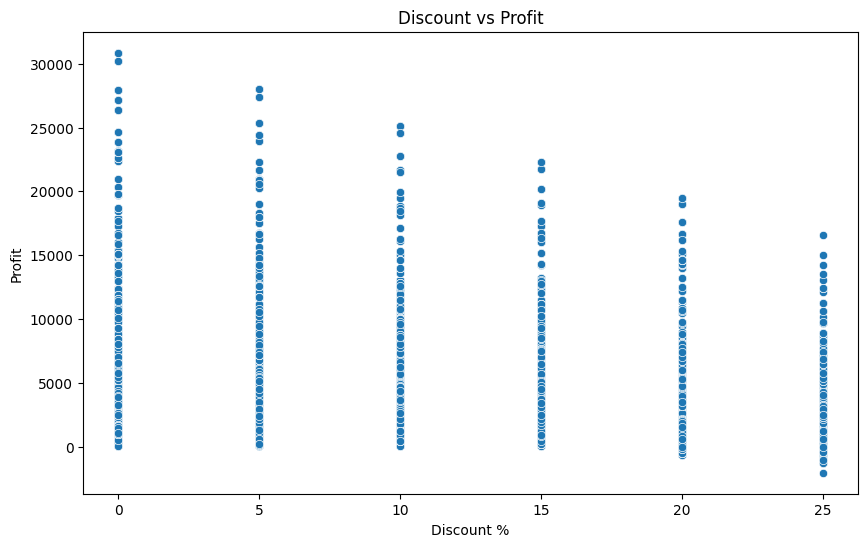

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df[df["OrderStatus"] == "Delivered"],
    x="DiscountPct",
    y="Profit"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount %")
plt.ylabel("Profit")

plt.show()

In [38]:
# Quantity vs Sales

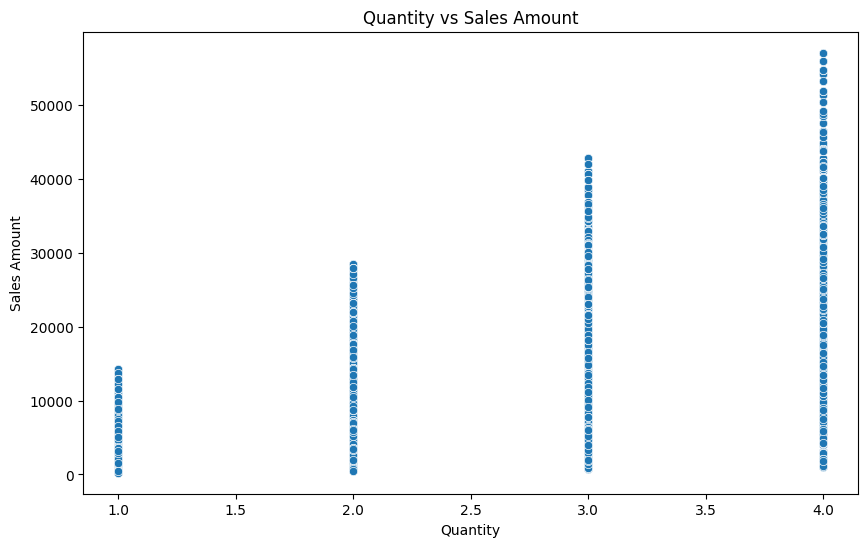

In [39]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df[df["OrderStatus"] == "Delivered"],
    x="Quantity",
    y="SalesAmount"
)

plt.title("Quantity vs Sales Amount")
plt.xlabel("Quantity")
plt.ylabel("Sales Amount")

plt.show()

In [40]:
# Correlation

In [41]:
numeric_cols = [
    "Age",
    "Quantity",
    "UnitPrice",
    "DiscountPct",
    "SalesAmount",
    "Profit"
]

In [42]:
correlation = df[numeric_cols].corr()

In [43]:
correlation

,Age,Quantity,UnitPrice,DiscountPct,SalesAmount,Profit
Age,1.000000,0.005574,-0.001661,-0.000709,0.000313,0.003488
Quantity,0.005574,1.000000,-0.000415,0.002037,0.588638,0.438354
UnitPrice,-0.001661,-0.000415,1.000000,-0.003870,0.727013,0.699047
DiscountPct,-0.000709,0.002037,-0.003870,1.000000,-0.111380,-0.235076
SalesAmount,0.000313,0.588638,0.727013,-0.111380,1.000000,0.907850
Profit,0.003488,0.438354,0.699047,-0.235076,0.907850,1.000000


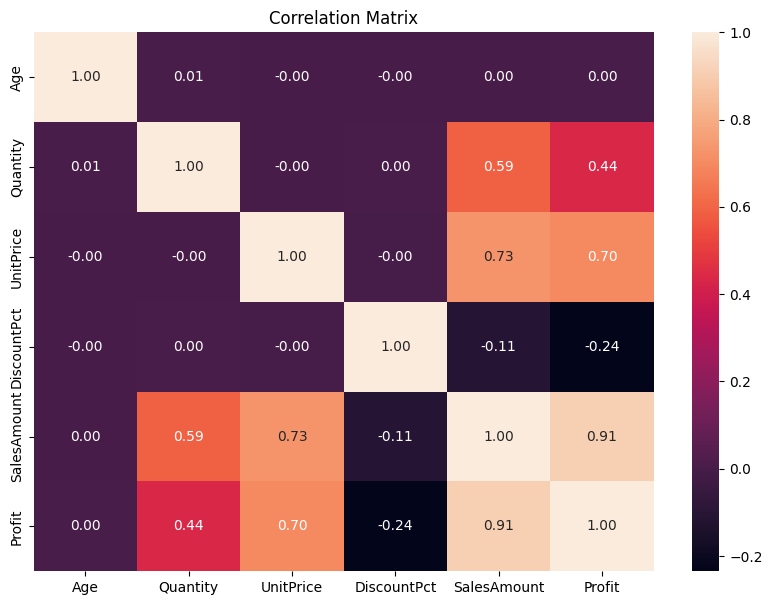

In [44]:
plt.figure(figsize=(10,7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [45]:
# Outlier Analysis

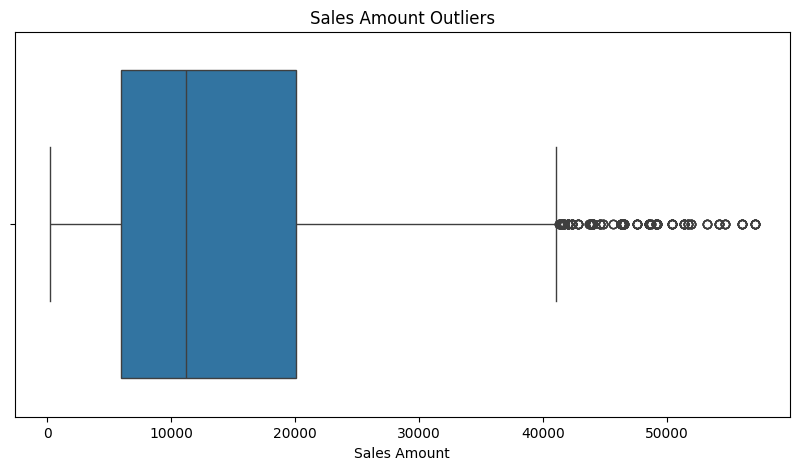

In [46]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["SalesAmount"]
)

plt.title("Sales Amount Outliers")
plt.xlabel("Sales Amount")

plt.show()

In [47]:
# Kaunse products sabse zyada revenue generate kar rahe hain?

In [48]:
top_products = (
    df[df["OrderStatus"] == "Delivered"]
    .groupby("ProductName")["SalesAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

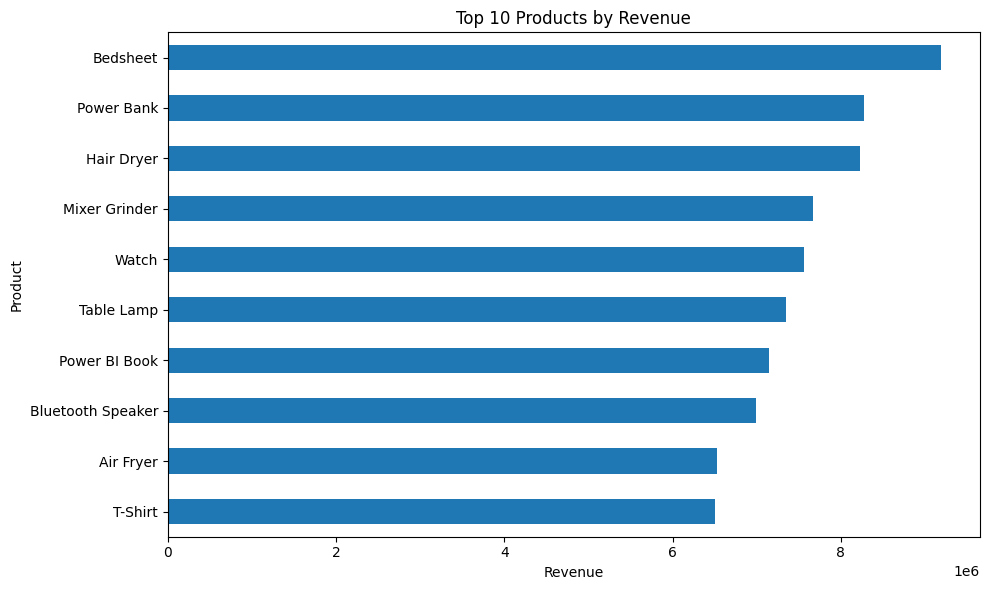

In [49]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [50]:
# Return Reason Analysis

In [57]:
import mysql.connector
import pandas as pd

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mysql123",
    database="ecommerce_analytics"
)

returns = pd.read_sql(
    "SELECT * FROM Returns",
    connection
)

returns.head()

C:\Users\abhil\AppData\Local\Temp\ipykernel_8348\1792112120.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  returns = pd.read_sql(


,ReturnID,OrderID,ReturnDate,ReturnReason
0,R00001,O00016,1970-01-01,Damaged
1,R00002,O00078,1970-01-01,Wrong Product
2,R00003,O00088,1970-01-01,Size Issue
3,R00004,O00124,1970-01-01,Size Issue
4,R00005,O00125,1970-01-01,Late Delivery


In [58]:
return_analysis = (
    returns
    .groupby("ReturnReason")
    .size()
    .sort_values(ascending=False)
)

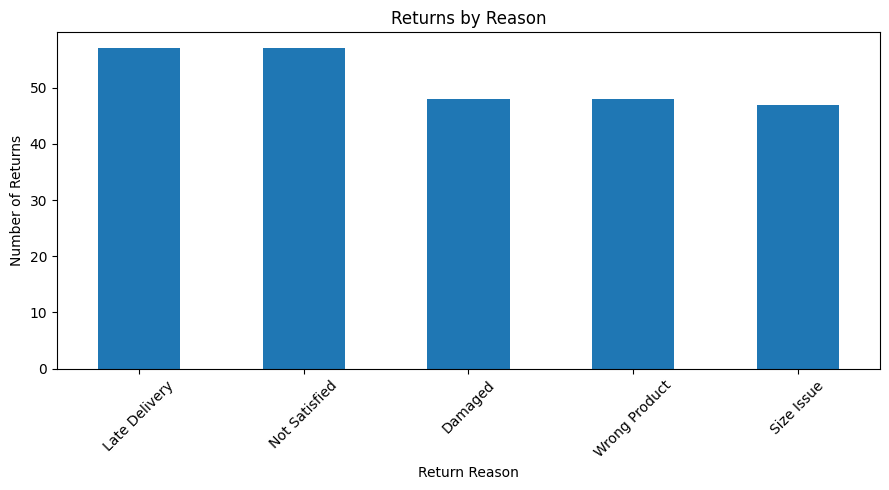

In [59]:
plt.figure(figsize=(9,5))

return_analysis.plot(kind="bar")

plt.title("Returns by Reason")
plt.xlabel("Return Reason")
plt.ylabel("Number of Returns")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
eda_summary = pd.DataFrame({
    "Analysis": [
        "Monthly Revenue",
        "Category Performance",
        "Region Performance",
        "Discount vs Profit",
        "Top Products",
        "Return Reasons"
    ],
    "Business_Purpose": [
        "Identify sales trend",
        "Find high-performing categories",
        "Compare regional performance",
        "Understand discount impact",
        "Identify important products",
        "Identify return problems"
    ]
})

eda_summary

,Analysis,Business_Purpose
0,Monthly Revenue,Identify sales trend
1,Category Performance,Find high-performing categories
2,Region Performance,Compare regional performance
3,Discount vs Profit,Understand discount impact
4,Top Products,Identify important products
5,Return Reasons,Identify return problems
